In [1]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses, optimizers, callbacks
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置随机种子 (Reproducibility)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. 读取上一阶段保存的数据
data_path = "../data/modeling_data_ready.pkl"
try:
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
    print("✅ 数据加载成功！")
except FileNotFoundError:
    print("❌ 错误：未找到数据文件，请检查路径。")

X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']

# 同时也读取 SMOTE 数据（用于后续的对比基准模型，SDAE主要用原始数据）
X_train_smote = data['X_train_smote']
y_train_smote = data['y_train_smote']

# 获取输入维度
input_dim = X_train.shape[1]
print(f"输入特征维度: {input_dim}")
print(f"训练集形状: {X_train.shape}")

e:\miniconda3\envs\GradProject\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


✅ 数据加载成功！
输入特征维度: 15
训练集形状: (4929, 15)


输入特征维度: 15
SDAE 训练数据 (仅正常用户): (3621, 15)

=== 1. 训练 SDAE (仅基于正常样本) ===
✅ SDAE 训练完成。

=== 验证重构误差分布 ===
            count      mean       std       min       25%       50%       75%  \
true_class                                                                      
0           518.0  0.087709  0.042908  0.009059  0.054994  0.086056  0.111383   
1           187.0  0.096688  0.040598  0.013602  0.071459  0.091701  0.117523   

                 max  
true_class            
0           0.248777  
1           0.242595  


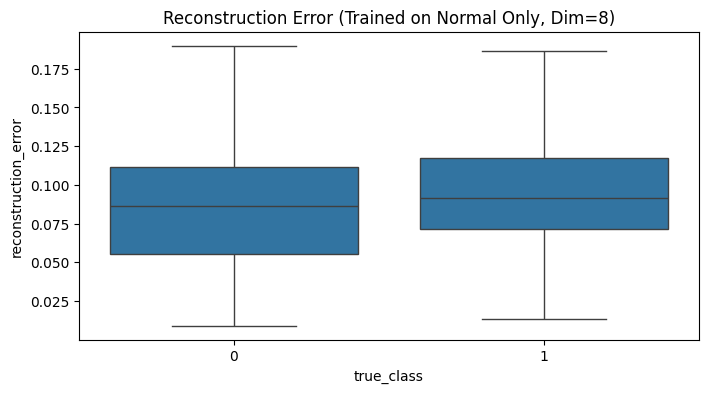

In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, optimizers, callbacks
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 数据准备
print(f"输入特征维度: {X_train.shape[1]}")

# === 关键步骤：只提取正常用户数据用于训练 SDAE ===
# 目的：建立“正常用户行为”的基准，任何偏离这个基准的（流失用户）都应该产生高误差或奇怪的特征
X_train_normal = X_train[y_train == 0]
X_val_normal = X_val[y_val == 0]

print(f"SDAE 训练数据 (仅正常用户): {X_train_normal.shape}")


# --- 模块 4.2.1: 修正后的 SDAE (压缩率更高) ---

def build_robust_sdae(input_dim, encoding_dim=8): # <--- 改为 8，强迫压缩
    input_layer = layers.Input(shape=(input_dim,))
    
    # 1. 强力降噪: Masking + Gaussian
    # 随机丢弃 20% 特征，并加入噪声
    masked_input = layers.Dropout(0.2)(input_layer)
    noisy_input = layers.GaussianNoise(0.1)(masked_input)
    
    # 2. 编码器
    # 15 -> 12 -> 8
    encoded = layers.Dense(12, activation='selu')(noisy_input)
    
    # Latent Layer (瓶颈层)
    # L1 正则化: 稀疏约束，提取最强特征
    latent = layers.Dense(encoding_dim, activation='relu', 
                          activity_regularizer=regularizers.l1(1e-5),
                          name='latent_layer')(encoded)
    
    # 3. 解码器
    # 8 -> 12 -> 15
    decoded = layers.Dense(12, activation='selu')(latent)
    output_layer = layers.Dense(input_dim, activation='linear')(decoded)
    
    autoencoder = keras.Model(inputs=input_layer, outputs=output_layer)
    encoder = keras.Model(inputs=input_layer, outputs=latent)
    
    return autoencoder, encoder

# --- 训练 SDAE (只看正常人) ---

print("\n=== 1. 训练 SDAE (仅基于正常样本) ===")
# encoding_dim=8, 约为输入的一半，强制提取核心信息
sdae, feature_extractor = build_robust_sdae(input_dim=X_train.shape[1], encoding_dim=8)

sdae.compile(optimizer='adam', loss='mse')

history = sdae.fit(
    X_train_normal, X_train_normal,  # <--- 输入和目标都是正常样本
    epochs=60,
    batch_size=64,
    shuffle=True,
    validation_data=(X_val_normal, X_val_normal),
    verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=8, restore_best_weights=True)]
)

print("✅ SDAE 训练完成。")

# --- 验证：看一下现在的重构误差分布 ---
print("\n=== 验证重构误差分布 ===")
X_test_pred = sdae.predict(X_test, verbose=0)
mse = np.mean(np.power(X_test_pred - X_test, 2), axis=1)
error_df = pd.DataFrame({'reconstruction_error': mse, 'true_class': y_test})

print(error_df.groupby('true_class')['reconstruction_error'].describe())

# 画图
plt.figure(figsize=(8, 4))
sns.boxplot(x='true_class', y='reconstruction_error', data=error_df, showfliers=False)
plt.title('Reconstruction Error (Trained on Normal Only, Dim=8)')
plt.show()


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
重构误差统计描述：
            count      mean       std       min       25%       50%       75%  \
true_class                                                                      
0           518.0  0.038481  0.020251  0.005714  0.024454  0.035619  0.046973   
1           187.0  0.041007  0.018896  0.007852  0.027642  0.038090  0.051732   

                 max  
true_class            
0           0.145572  
1           0.126305  


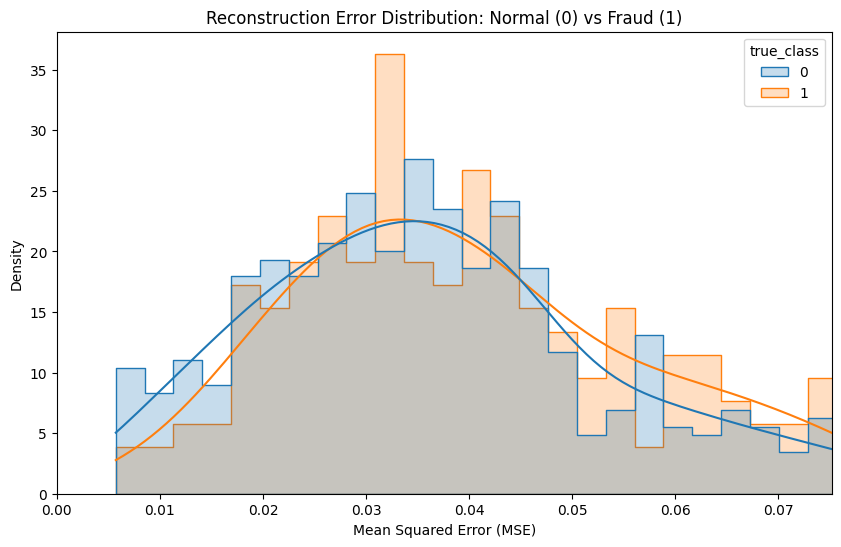

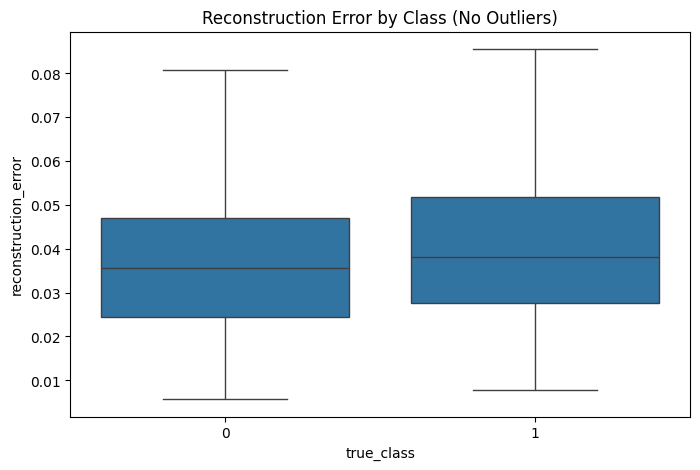

In [8]:
# 1. 使用 Autoencoder 对测试集进行预测（重构）
X_test_pred = sdae.predict(X_test)

# 2. 计算每个样本的均方误差 (MSE)
# axis=1 表示对每个样本的所有特征求平均
test_mae = np.mean(np.abs(X_test_pred - X_test), axis=1)
test_mse = np.mean(np.power(X_test_pred - X_test, 2), axis=1)

# 创建一个 DataFrame 方便画图
error_df = pd.DataFrame({
    'reconstruction_error': test_mse,
    'true_class': y_test
})

print("重构误差统计描述：")
print(error_df.groupby('true_class')['reconstruction_error'].describe())

# 3. 可视化：正常交易 vs 欺诈交易 的重构误差分布
plt.figure(figsize=(10, 6))
sns.histplot(data=error_df, x='reconstruction_error', hue='true_class', 
             bins=50, kde=True, element="step", stat="density", common_norm=False)
plt.title('Reconstruction Error Distribution: Normal (0) vs Fraud (1)')
plt.xlabel('Mean Squared Error (MSE)')
plt.xlim(0, error_df['reconstruction_error'].quantile(0.95)) # 限制x轴范围以防极值影响观察
plt.show()

# 4. 箱线图对比（更能看清中位数的差异）
plt.figure(figsize=(8, 5))
sns.boxplot(x='true_class', y='reconstruction_error', data=error_df, showfliers=False)
plt.title('Reconstruction Error by Class (No Outliers)')
plt.show()

In [ ]:
# --- 模块 4.2.2 & 4.2.3: 集成欠采样 + 代价敏感分类 ---

def build_cost_sensitive_classifier(input_dim):
    """构建简单的分类器 (MLP)"""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='selu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy', # 权重在 fit 时通过 class_weight 传入
                  metrics=['AUC'])
    return model

print("\n=== 2. 开始 Bagging 集成训练 (Ensemble Undersampling) ===")

# 1. 拆分多数类和少数类
X_maj = X_train[y_train == 0] # 正常用户
X_min = X_train[y_train == 1] # 欺诈/流失用户 (少数类)
y_maj = y_train[y_train == 0]
y_min = y_train[y_train == 1]

n_minority = len(X_min)
n_majority = len(X_maj)

# 2. 决定 Bagging 的数量 (多少个子模型)
# 例如：如果多数类是少数类的 10 倍，我们就可以训练 10 个模型，覆盖所有多数类数据
n_estimators = int(n_majority / n_minority)
print(f"集成模型数量 (Bags): {n_estimators}")

# 存储所有子模型
ensemble_models = []

# 3. 设置代价敏感权重 (Cost-Sensitive)
# w0 = 1, w1 = 5 (对漏报的惩罚是误报的5倍，可根据业务调整)
class_weights = {0: 1.0, 1: 5.0} 

# 4. 循环训练子模型
# 为了随机性，先打乱多数类
X_maj_shuffled = shuffle(X_maj, random_state=SEED)

for i in range(n_estimators):
    print(f"Training Estimator {i+1}/{n_estimators}...", end="\r")
    
    # A. 欠采样：切片取出这一份的多数类样本
    start_idx = i * n_minority
    end_idx = (i + 1) * n_minority
    
    # 如果最后不够了，就取剩下的
    if i == n_estimators - 1:
        X_maj_batch = X_maj_shuffled[start_idx:]
    else:
        X_maj_batch = X_maj_shuffled[start_idx:end_idx]
        
    y_maj_batch = np.zeros(len(X_maj_batch))
    
    # B. 组合：这一份多数类 + 全部的少数类
    X_batch = np.concatenate([X_maj_batch, X_min], axis=0)
    y_batch = np.concatenate([y_maj_batch, y_min], axis=0)
    
    # 打乱当前 batch
    X_batch, y_batch = shuffle(X_batch, y_batch, random_state=SEED+i)
    
    # C. 特征提取：通过 SDAE 提取 Latent 特征
    # 注意：这里我们使用 .predict 提取特征，不再更新 SDAE 的权重
    X_batch_features = feature_extractor.predict(X_batch, verbose=0)
    
    # D. 训练分类器 (代价敏感)
    clf = build_cost_sensitive_classifier(input_dim=16) # 输入维度是 latent dim
    
    clf.fit(
        X_batch_features, y_batch,
        epochs=30,
        batch_size=32,
        class_weight=class_weights, # <--- 模块 4.2.3 的核心：加权损失
        verbose=0
    )
    
    ensemble_models.append(clf)

print(f"\n✅ 集成模型训练完成，共 {len(ensemble_models)} 个子分类器。")


# --- 模型评估 (集成预测) ---

print("\n=== 3. 最终模型评估 (Ensemble Voting) ===")

# 1. 对测试集提取特征
X_test_features = feature_extractor.predict(X_test, verbose=0)

# 2. 让每个子模型进行预测
y_preds_all = []
for clf in ensemble_models:
    pred = clf.predict(X_test_features, verbose=0)
    y_preds_all.append(pred)

# 3. 平均预测结果 (Soft Voting)
y_pred_ensemble_prob = np.mean(y_preds_all, axis=0)
y_pred_ensemble_class = (y_pred_ensemble_prob > 0.5).astype(int)

# 4. 输出指标
auc = roc_auc_score(y_test, y_pred_ensemble_prob)
print(f"Ensemble ROC-AUC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble_class))

# 5. 混淆矩阵
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_ensemble_class), annot=True, fmt='d', cmap='Oranges')
plt.title(f'Ensemble Result (Bags={n_estimators}, Weighted)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()